In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 7
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  7 0.4500000000000001 0.40000000000000013
-------  14 0.4250000000000001 0.4500000000000002
-------  21 0.47500000000000014 0.4750000000000002
-------  28 0.5000000000000002 0.5000000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  42 0.4250000000000001 0.5750000000000003
-------  49 0.4500000000000001 0.6000000000000003
-------  56 0.4500000000000001 0.6250000000000003
-------  63 0.4500000000000001 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  84 0.4500000000000001 0.7250000000000004
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.87500000000

In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  0 , total integrated cost =  13557.205108931135
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  14 0.4250000000000001 0.4500000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.175560697715
Gradient descend method:  None
RUN  0 , total integrated cost =  8796.175560697715
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  21 0.47500000000000014 0.47500000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1501.3490007755165
RUN  2 , total integrated cost =  698.5504480763045
RUN  3 , total integrated cost =  463.94991457517654
RUN  4 , total integrated cost =  327.3038219470977
RUN  5 , total integrated cost =  247.1369560477097
RUN  6 , total integrated cost =  195.03030637097507
RUN  7 , total integrated cost =  156.9276183414355
RUN  8 , total integrated cost =  128.4202582510654
RUN  9 , total integrated cost =  107.1821148020227
RUN  10 , total integrated cost =  89.10047297145616
RUN  11 , total integrated cost =  75.3982503998006
RUN  12 , total integrated cost =  63.490770026827406
RUN  13 , total integrated cost =  55.393846512076806
RUN  14 , total integrated cost =  50.00968969913001
RUN  15 , total integrated cost =  45.59106379553283
RUN  16 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  362 , total integrated cost =  5379.979985628796
Improved over  362  iterations in  23.9380690343678  seconds by  8.769570269262488  percent.
Problem in initial value trasfer:  Vmean_exc -56.626856870105435 -56.62686001380965
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13557.205108931135
Gradient descend method:  None
RUN  1 , total integrated cost =  1941.711518783814
RUN  2 , total integrated cost =  1240.491108357753
RUN  3 , total integrated cost =  860.998276075921
RUN  4 , total integrated cost =  618.5133992043548
RUN  5 , total integrated cost =  456.80981098276953
RUN  6 , total integrated cost =  347.67043042264703
RUN  7 , total integrated cost =  270.5356144897221
RUN  8 , total integrated cost =  215.95030933518348
RUN  9 , total integrated cost =  176.42568333619465
RUN  10 , total integrated cost =  147.08286096583245
RUN  11 

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  7.991623834827296
RUN  2000 , total integrated cost =  7.991623834827296
Improved over  2000  iterations in  133.90536877326667  seconds by  99.94105257115596  percent.
Problem in initial value trasfer:  Vmean_exc -56.67416850727075 -56.67416844788965
weight =  16964.268325354828
set cost params:  1.0 16964.268325354828 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13552.376767560994
Gradient descend method:  None
RUN  1 , total integrated cost =  13327.497657227997
RUN  2 , total integrated cost =  13325.986713588612
RUN  3 , total integrated cost =  13325.198425541877
RUN  4 , total integrated cost =  13302.073987446927
RUN  5 , total integrated cost =  13284.590253642169
RUN  6 , total integrated cost =  13284.409166723732
RUN  7 , total integrated cost =  13281.588141914584
RUN  8 , total integrated cost =  13279.37006792536
RUN  9 , total integrated cost =  13279.191429957073
RUN  10 , total integrated cost =  1327

...

RUN  3 , total integrated cost =  23752.516484597752
RUN  4 , total integrated cost =  23752.516484597752
Control only changes marginally.
RUN  4 , total integrated cost =  23752.516484597752
Improved over  4  iterations in  0.3597778473049402  seconds by  1.444422537133505e-07  percent.
Problem in initial value trasfer:  Vmean_exc -73.23567679919041 -73.2357044845899
weight =  10.000000014444227
set cost params:  1.0 10.000000014444227 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23752.516484597756
Gradient descend method:  None
RUN  1 , total integrated cost =  23752.516484597752
RUN  2 , total integrated cost =  23752.51648459775


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  23752.51648459775
Control only changes marginally.
RUN  3 , total integrated cost =  23752.51648459775
Improved over  3  iterations in  0.30575684271752834  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -73.23567680083345 -73.23570448622534
-------  126 0.5000000000000002 0.8500000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.9785373305
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537298888
RUN  2 , total integrated cost =  19001.978537298877


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  19001.978537298877
Control only changes marginally.
RUN  3 , total integrated cost =  19001.978537298877
Improved over  3  iterations in  0.2666646558791399  seconds by  1.6640910871501546e-10  percent.
Problem in initial value trasfer:  Vmean_exc -75.95963723057139 -75.95963806258354
weight =  10.000000000016641
set cost params:  1.0 10.000000000016641 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19001.978537298877
Gradient descend method:  None
RUN  1 , total integrated cost =  19001.978537298877
Control only changes marginally.
RUN  1 , total integrated cost =  19001.978537298877
Improved over  1  iterations in  0.13691262528300285  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.95963723057139 -75.95963806258354
-------  133 0.47500000000000014 0.8750000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14446.643021512598
Gradient

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


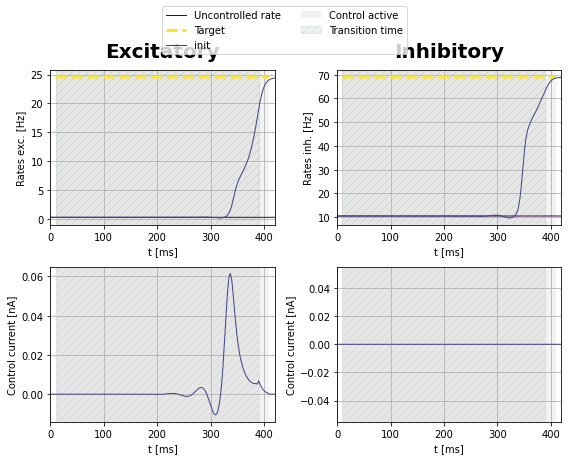

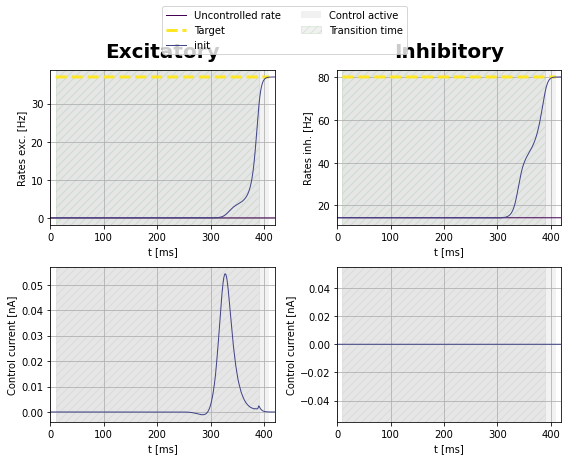

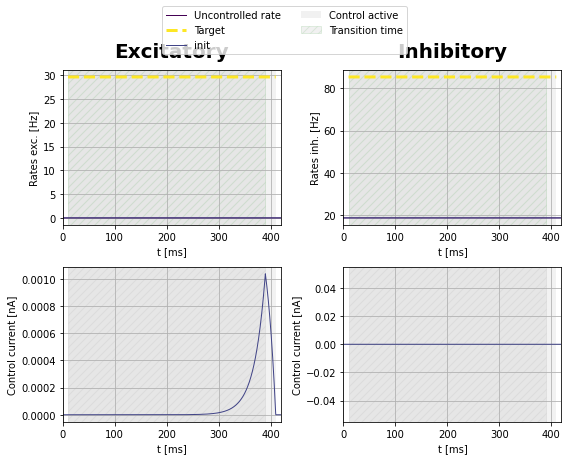

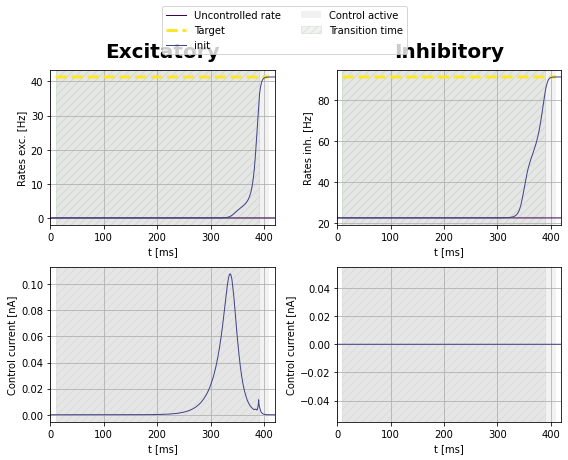

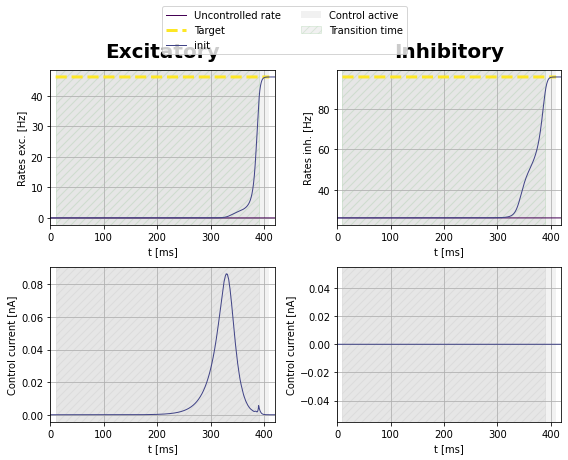

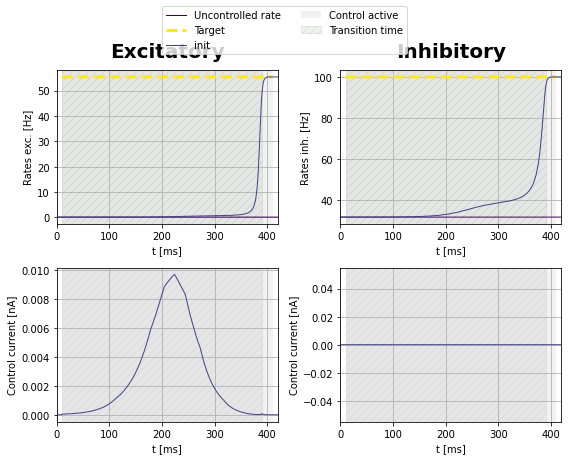

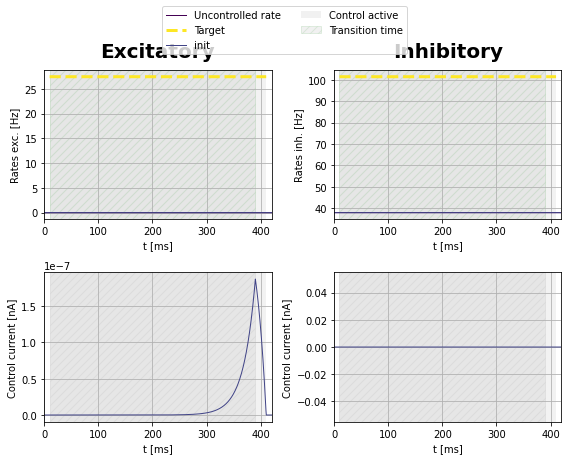

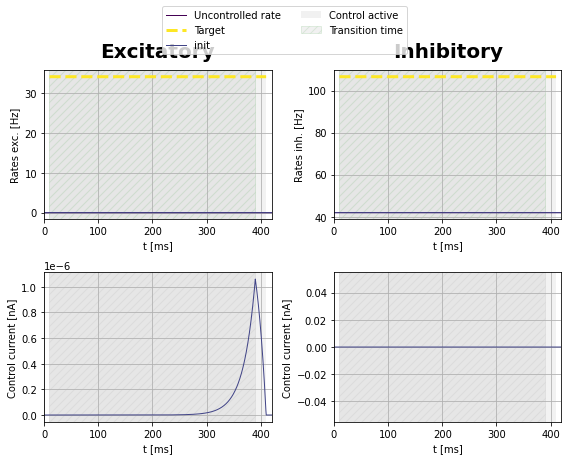

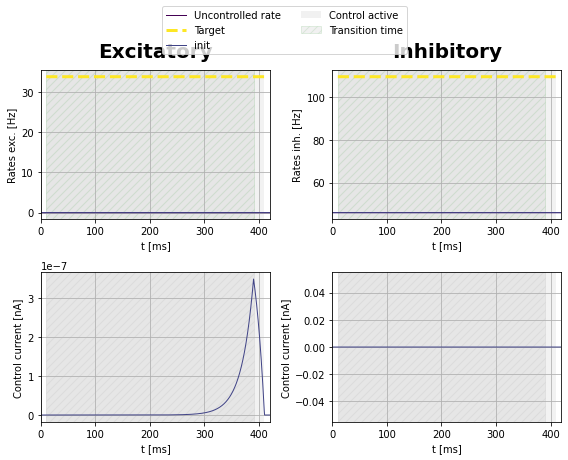

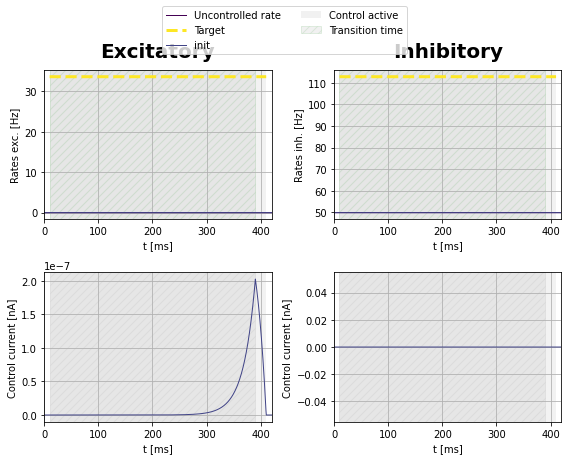

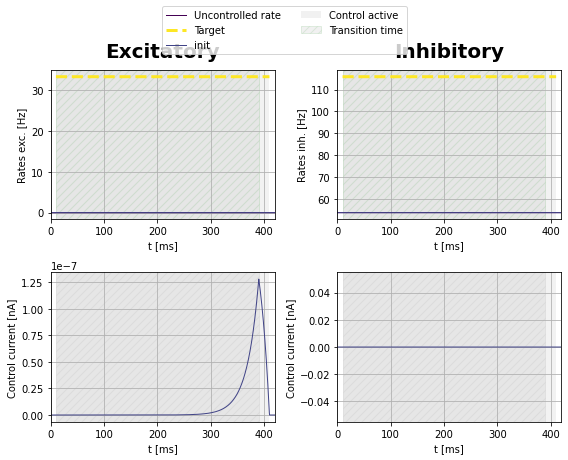

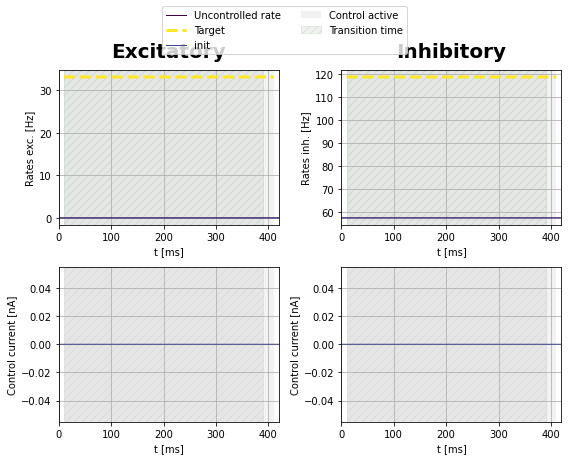

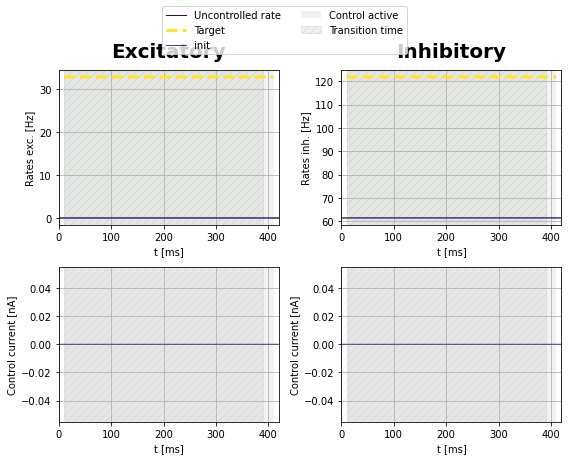

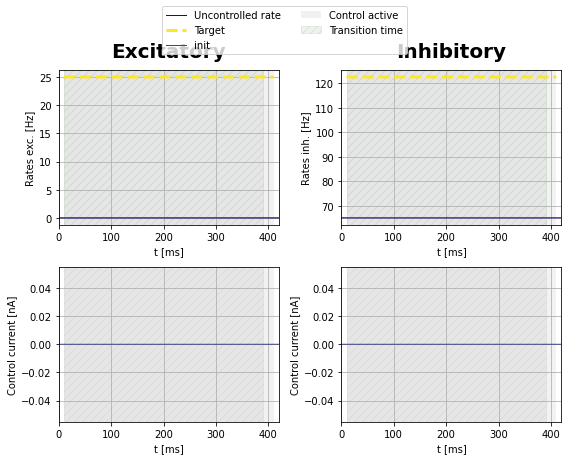

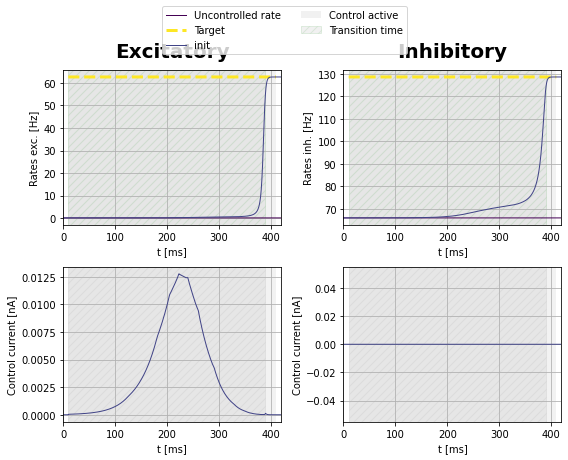

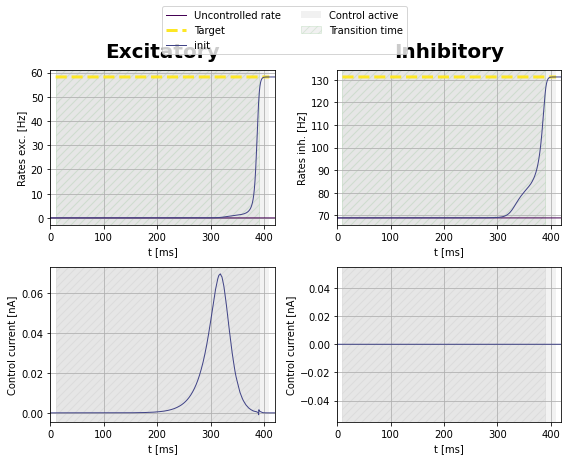

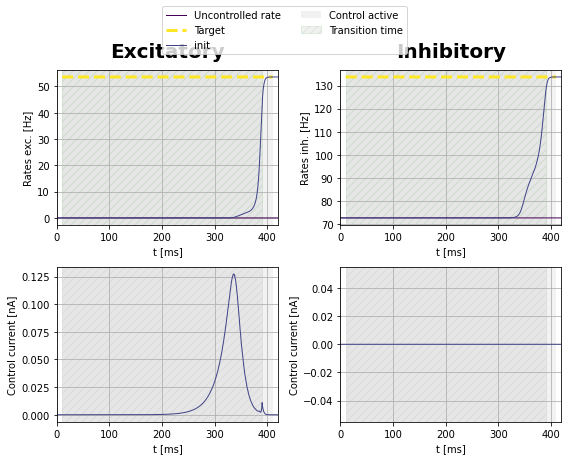

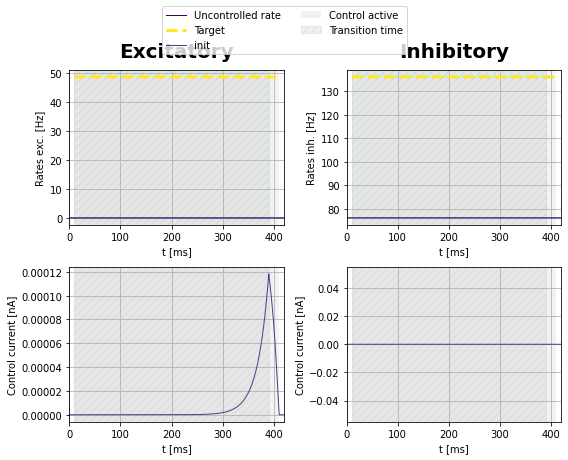

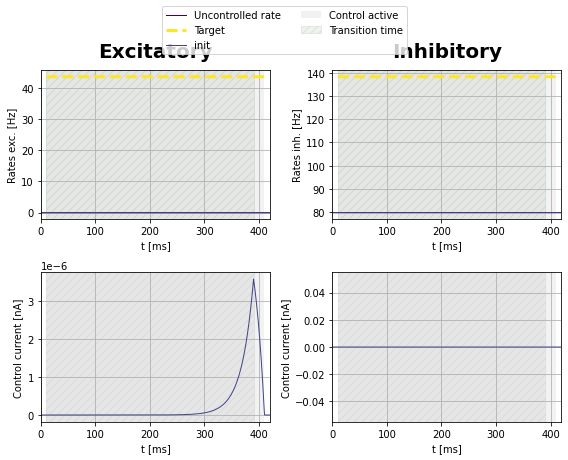

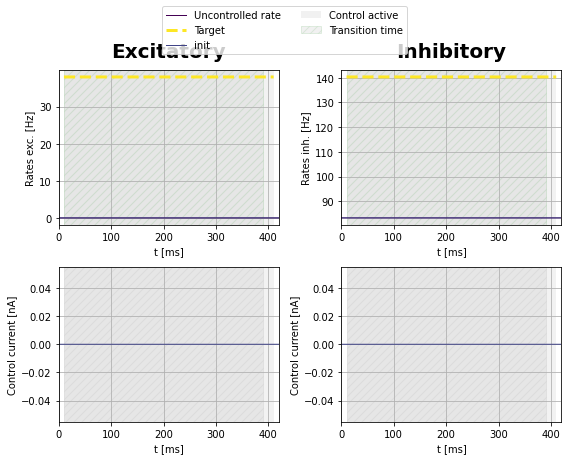

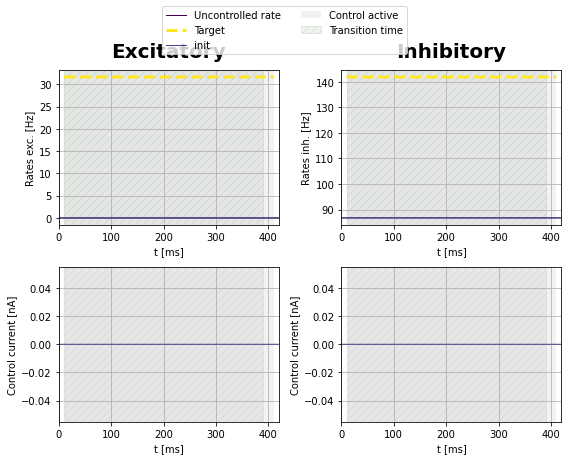

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  7 0.4500000000000001 0.40000000000000013
found solution for  7
-------  14 0.4250000000000001 0.4500000000000002
[0, 7] []
closest index  7
set c

ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  8796.172946701312
RUN  6 , total integrated cost =  8796.172946701312
Control only changes marginally.
RUN  6 , total integrated cost =  8796.172946701312
Improved over  6  iterations in  0.5487101878970861  seconds by  0.08730276116530433  percent.
Problem in initial value trasfer:  Vmean_exc -71.30990819295886 -71.31015346908723
weight =  10.000002971742846
set cost params:  1.0 10.000002971742846 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8796.172946702065
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8796.172946702063
RUN  2 , total integrated cost =  8796.172946702063
Control only changes marginally.
RUN  2 , total integrated cost =  8796.172946702063
Improved over  2  iterations in  0.2564056757837534  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -71.30990819296407 -71.31015346909241
-------  21 0.47500000000000014 0.4750000000000002
found solution for  21
-------  28 0.5000000000000002 0.5000000000000002
found solution for  28
-------  35 0.5500000000000003 0.5250000000000002
found solution for  35
-------  42 0.4250000000000001 0.5750000000000003
[0, 7, 21, 28, 35] []
closest index  28
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7545.8087549930315
Gradient descend method:  None
RUN  1 , total integrated cost =  7519.190004972385
RUN  2 , total integrated cost =  7519.1835066262865
RUN  3 , total integrated cost =  7519.18

...

RUN  14 , total integrated cost =  11607.540239736536
Control only changes marginally.
RUN  14 , total integrated cost =  11607.540239736536
Improved over  14  iterations in  1.0067848321050406  seconds by  0.07688495244173055  percent.
Problem in initial value trasfer:  Vmean_exc -56.662167875453186 -56.662170671806436
-------  56 0.4500000000000001 0.6250000000000003
[0, 7, 21, 28, 35, 98, 105, 112, 119, 126, 133, 140, 70, 91] [28, 35, 21, 105, 98]
closest index  70
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  258.74189429534704
Gradient descend method:  None
RUN  1 , total integrated cost =  227.04698923251578
RUN  2 , total integrated cost =  220.01381246197866
RUN  3 , total integrated cost =  215.06467633178346
RUN  4 , total integrated cost =  210.59253940331485
RUN  5 , total integrated cost =  206.29306132845073
RUN  6 , total integrated cost =  201.5850251412488
RUN  7 , total integrated cost =  2

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  11430.109720579989
Control only changes marginally.
RUN  11 , total integrated cost =  11430.109720579989
Improved over  11  iterations in  0.8696648608893156  seconds by  0.05563507746653329  percent.
Problem in initial value trasfer:  Vmean_exc -56.661026854809606 -56.66102968161748
-------  63 0.4500000000000001 0.6500000000000004
[0, 7, 21, 28, 35, 98, 105, 112, 119, 126, 133, 140, 70, 91] [28, 35, 105, 21, 98]
closest index  70
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  259.14166236974097
Gradient descend method:  None
RUN  1 , total integrated cost =  227.07590030981788
RUN  2 , total integrated cost =  218.98025665862332
RUN  3 , total integrated cost =  215.3352702332569
RUN  4 , total integrated cost =  214.52894383730344
RUN  5 , total integrated cost =  214.25361775196427
RUN  6 , total integrated cost =  214.19212403862466
RUN  7 , total integrated cost =  21

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  11260.092634447079
Control only changes marginally.
RUN  17 , total integrated cost =  11260.092634447079
Improved over  17  iterations in  1.1952644661068916  seconds by  0.06498756230107006  percent.
Problem in initial value trasfer:  Vmean_exc -56.659931698648855 -56.65993462922479
-------  70 0.4500000000000001 0.6750000000000004
-------  77 0.4500000000000001 0.7000000000000004
found solution for  77
-------  84 0.4500000000000001 0.7250000000000004
found solution for  84
-------  91 0.4250000000000001 0.7500000000000004
-------  98 0.6000000000000003 0.7500000000000004
-------  105 0.5750000000000002 0.7750000000000005
-------  112 0.5500000000000003 0.8000000000000005
-------  119 0.5250000000000001 0.8250000000000005
-------  126 0.5000000000000002 0.8500000000000005
-------  133 0.47500000000000014 0.8750000000000006
-------  140 0.4500000000000001 0.9000000000000006
------------------------------------------------------------
---------------

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  7052.813223729279
set cost params:  1.0 7052.813223729279 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5894.920522495465
Gradient descend method:  None
RUN  1 , total integrated cost =  5894.678655818221
RUN  2 , total integrated cost =  5894.676919274599
RUN  3 , total integrated cost =  5894.676653964237
RUN  4 , total integrated cost =  5894.676598008892
RUN  5 , total integrated cost =  5894.676585275488
RUN  6 , total integrated cost =  5894.676581938037
RUN  7 , total integrated cost =  5894.6765805140985
RUN  8 , total integrated cost =  5894.67

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  24 , total integrated cost =  5894.6765794404855
Improved over  24  iterations in  1.6837490927428007  seconds by  0.004138190736398428  percent.
Problem in initial value trasfer:  Vmean_exc -56.62680151548831 -56.62680519506334
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  17413.173142931282
set cost params:  1.0 17413.173142931282 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13554.440113069075
Gradient descend method:  None
RUN  1 , total integrated cost =  13554.42900834074
RUN  2 , total integrated cost =  13554.428385106752
RUN  3 , total integrated cost =  13554.428168485005
RUN  4 , total integrated cost =  13554.428090741609
RUN  5 , total integrated cost =  13554.428058127058
RUN  6 , total integrated cost =  13554.428045013128
RUN  7 , total integrated cost =  13554.428039015784
RUN  8 , total integrated cost =  13554.42803630275
RUN  9 , total integrated cost =  13554.4280349830

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  28 , total integrated cost =  13554.428033122786
Improved over  28  iterations in  1.9469927586615086  seconds by  8.912169140273818e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.67398525207816 -56.67398963296295
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  1094.0612451067745
set cost params:  1.0 1094.0612451067745 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8788.130728014463
Gradient descend method:  None
RUN  1 , total integrated cost =  8788.130726830614
RUN  2 , total integrated cost =  8788.130726759431
RUN  3 , total integrated cost =  8788.130726757188


...

RUN  1 , total integrated cost =  17065.15421136694
Control only changes marginally.
RUN  1 , total integrated cost =  17065.15421136694
Improved over  1  iterations in  0.1876832004636526  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68749521683597 -56.687495862303855
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  84 0.4500000000000001 0.7250000000000004
converged for  84
-------  91 0.4250000000000001 0.7500000000000004
converged for  91
-------  98 0.600000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  39221.33359373684
Control only changes marginally.
RUN  1 , total integrated cost =  39221.33359373684
Improved over  1  iterations in  0.19978196918964386  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69976861968311 -56.699768598955394
-------  105 0.5750000000000002 0.7750000000000005
converged for  105
-------  112 0.5500000000000003 0.8000000000000005
no convergence
weight =  5349.996987098493
set cost params:  1.0 5349.996987098493 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28710.175438783175
Gradient descend method:  None
RUN  1 , total integrated cost =  28710.17543878317
RUN  2 , total integrated cost =  28710.17543878317
Control only changes marginally.
RUN  2 , total integrated cost =  28710.17543878317
Improved over  2  iterations in  0.34907281771302223  seconds by  1.4210854715202004e-14  percent.
-------  119 0.5250000000000001 0.8250000000000005
no convergence
weight =  2438.

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23742.778369423588
Control only changes marginally.
RUN  1 , total integrated cost =  23742.778369423588
Improved over  1  iterations in  0.18683848716318607  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70096377533579 -56.70096368618202
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
[[False, False], [True, True], [False, False], [False, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, False], [True, False], [True, True], [False, False], [True, True], [False, False], [False, False], [True, False], [True, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.450000000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  88.57724779774283
Gradient descend method:  None
RUN  1 , total integrated cost =  14.5811619612594
RUN  2 , total integrated cost =  13.460531327328193
RUN  3 , total integrated cost =  13.30663025513914
RUN  4 , total integrated cost =  13.276607303946633
RUN  5 , total integrated cost =  13.25246601518718
RUN  6 , total integrated cost =  13.19798613527453
RUN  7 , total integrated cost =  13.183563263454671
RUN  8 , total integrated cost =  13.174485398467723
RUN  9 , total integrated cost =  13.168422781135954
RUN  10 , total integrated cost =  13.16782121656828
RUN  11 , total integrated cost =  13.166977919836066
RUN  12 , total integrated cost =  13.166358685918418
RUN  13 , total integrated cost =  13.165312036698216
RUN  14 , total integrated cost =  13.16454870665804
RUN  15 , total integrated cost =  13.162775042318275
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  389 , total integrated cost =  48.414331164173575
Improved over  389  iterations in  72.21224893257022  seconds by  36.306418832827184  percent.
Problem in initial value trasfer:  Vmean_exc -56.62777583166032 -56.62777301613399
weight =  12190.444841452529
set cost params:  1.0 12190.444841452529 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5889.346557437815
Gradient descend method:  None
RUN  1 , total integrated cost =  5782.720436405123
RUN  2 , total integrated cost =  5726.4625973245065
RUN  3 , total integrated cost =  5328.183614225832
RUN  4 , total integrated cost =  5303.975206392672
RUN  5 , total integrated cost =  5276.714083637939
RUN  6 , total integrated cost =  5258.55969858267
RUN  7 , total integrated cost =  5224.213420147934
RUN  8 , total integrated cost =  5206.144903352699
RUN  9 , total integrated cost =  5174.797843384091
RUN  10 , total integrated cost =  5157.856478655316
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  392 , total integrated cost =  3608.0296502510478
Improved over  392  iterations in  51.87275802716613  seconds by  38.736333223685584  percent.
Problem in initial value trasfer:  Vmean_exc -56.6269912832578 -56.626994567498016
-------  7 0.4500000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  89.68165426532259
Gradient descend method:  None
RUN  1 , total integrated cost =  12.76760805180553
RUN  2 , total integrated cost =  12.710932401801031
RUN  3 , total integrated cost =  12.705663248909977
RUN  4 , total integrated cost =  12.701083066684296
RUN  5 , total integrated cost =  12.697670988180281
RUN  6 , total integrated cost =  12.693862105085831
RUN  7 , total integrated cost =  12.69087928357363
RUN  8 , total integrated cost =  12.687365510568487
RUN  9 , total integrated cost =  12.684442134408648
RUN  10 , total integrated cost =  12.679305173931072
RUN

...

RUN  9 , total integrated cost =  14420.686983513302
Control only changes marginally.
RUN  9 , total integrated cost =  14420.686983513302
Improved over  9  iterations in  2.0101256519556046  seconds by  0.02043753494682221  percent.
Problem in initial value trasfer:  Vmean_exc -56.6768172060047 -56.676817385171
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  79.74556030836662
Gradient descend method:  None
RUN  1 , total integrated cost =  76.96291519520754
RUN  2 , total integrated cost =  76.9593851782034
RUN  3 , total integrated cost =  76.95486296342457
RUN  4 , total integrated cost =  76.95098598041719
RUN  5 , total integrated cost =  76.94558529846798
RUN  6 , total integrated cost =  76.94204862598325
RUN  7 , total integrated cost =  76.93987433657968
RUN  8 , total integrated cost =  76.9382319104192
RUN  9 , total integrated cost =  76.93819309938979
RUN  10 , total i

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  718 , total integrated cost =  2939.392550240975
Improved over  718  iterations in  139.15827363915741  seconds by  0.6368108230933132  percent.
Problem in initial value trasfer:  Vmean_exc -56.651557677232006 -56.65156078108852
weight =  339.8856880228815
set cost params:  1.0 339.8856880228815 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9989.774389802522
Gradient descend method:  None
RUN  1 , total integrated cost =  9988.891316361816
RUN  2 , total integrated cost =  9988.889291879008
RUN  3 , total integrated cost =  9988.888950502556
RUN  4 , total integrated cost =  9988.885790123406
RUN  5 , total integrated cost =  9988.883015180741
RUN  6 , total integrated cost =  9988.880012475023
RUN  7 , total integrated cost =  9988.876796533812
RUN  8 , total integrated cost =  9988.874098118764
RUN  9 , total integrated cost =  9988.87137282098
RUN  10 , total integrated cost =  9988.871368587079
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  9988.866275253638
Control only changes marginally.
RUN  17 , total integrated cost =  9988.866275253638
Improved over  17  iterations in  3.4859999418258667  seconds by  0.009090441019480977  percent.
Problem in initial value trasfer:  Vmean_exc -56.65145947641253 -56.65146422365073


/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/utils/plotFunctions.py:542: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


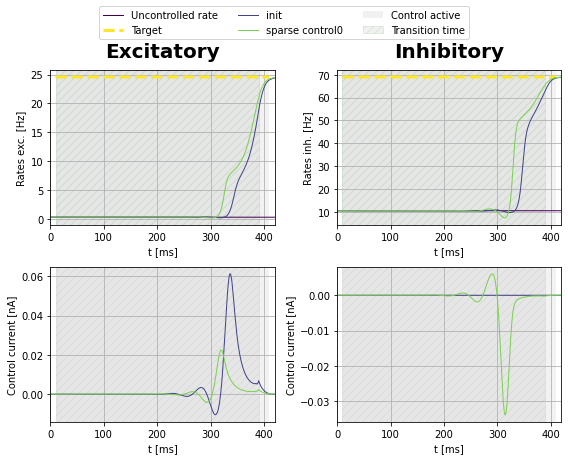

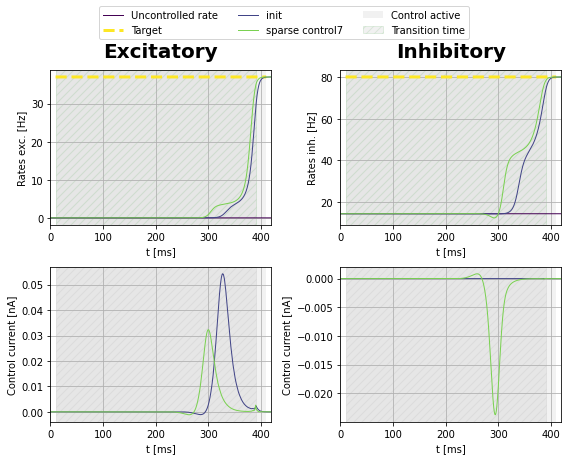

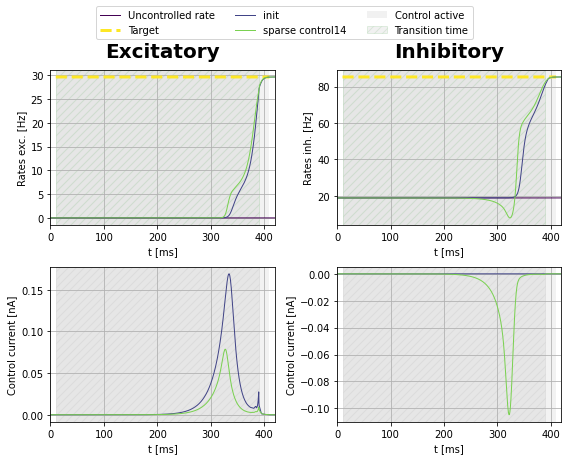

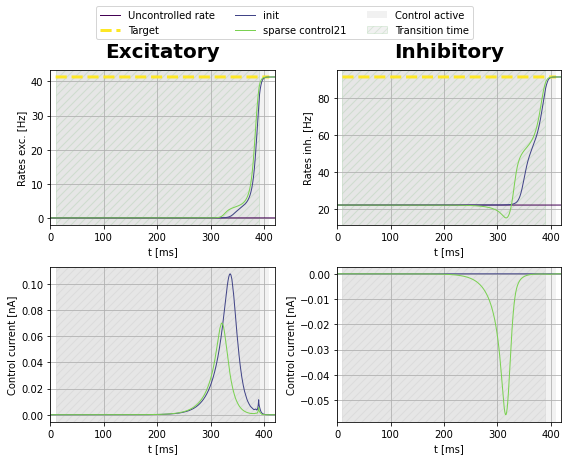

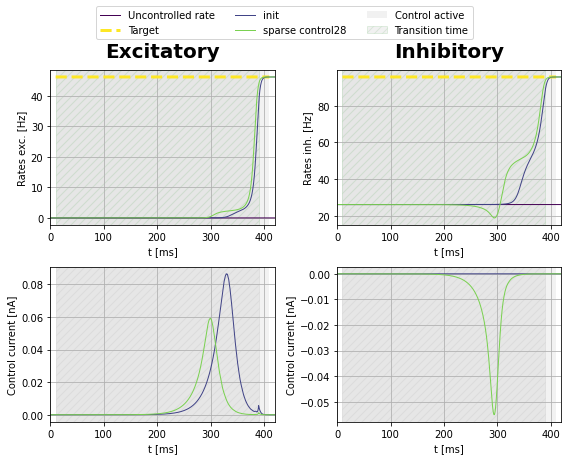

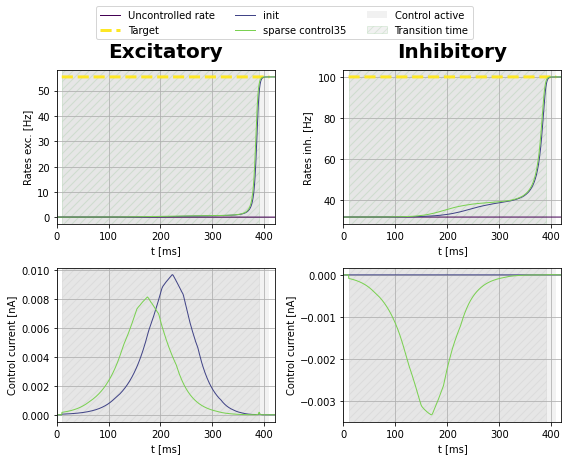

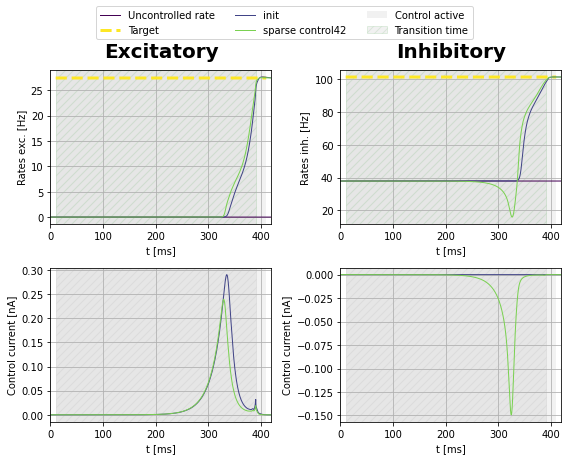

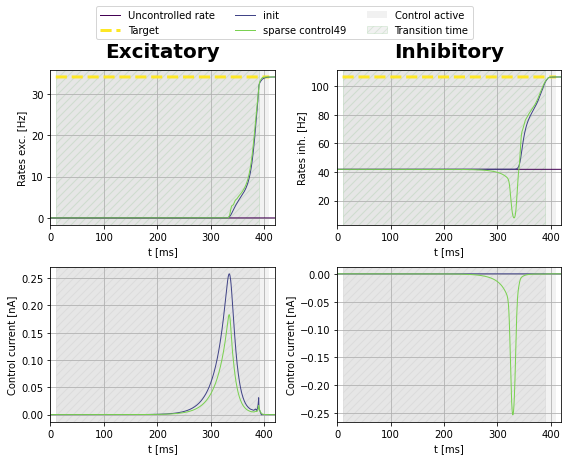

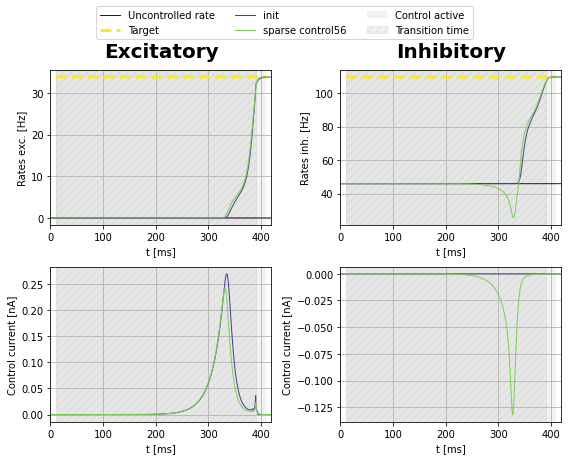

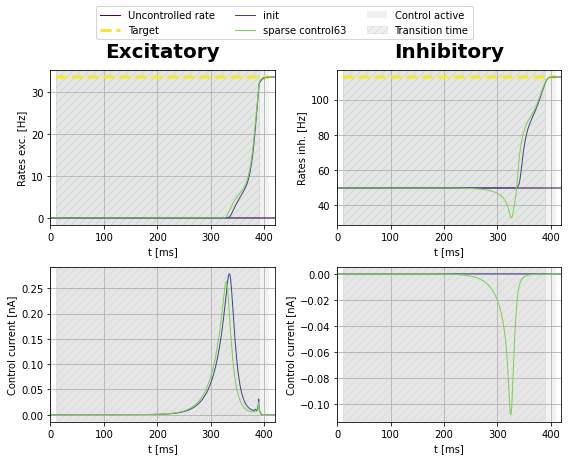

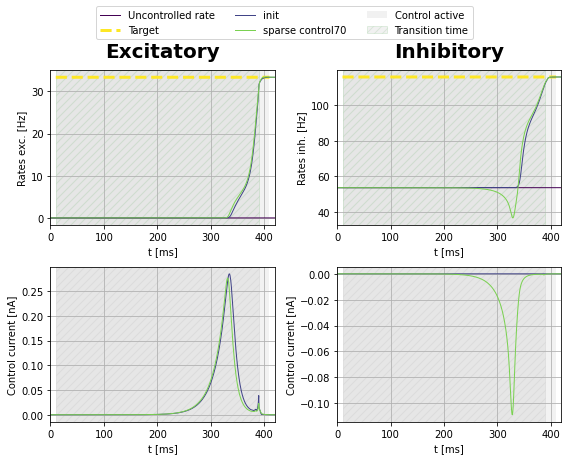

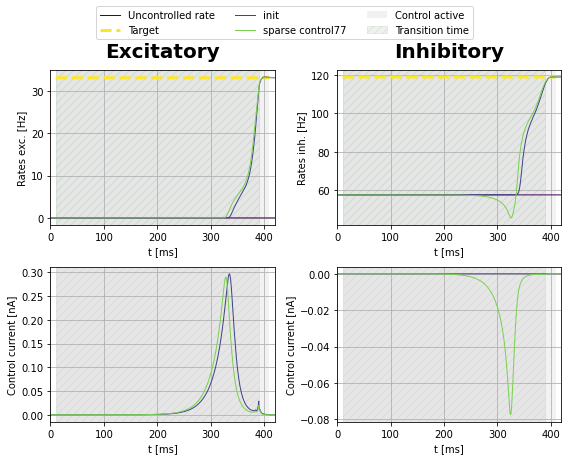

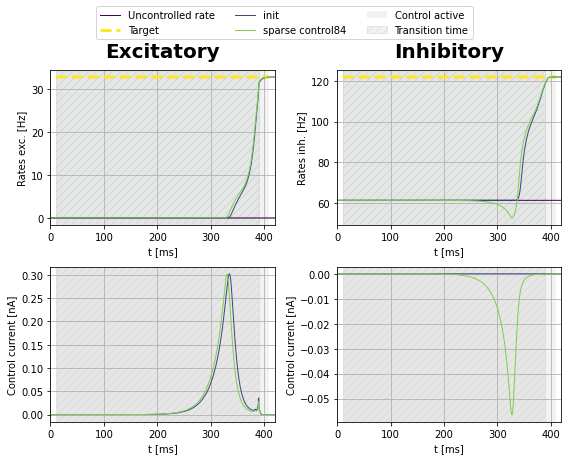

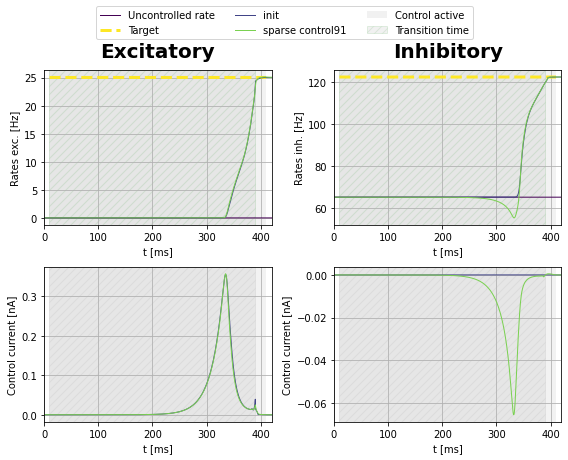

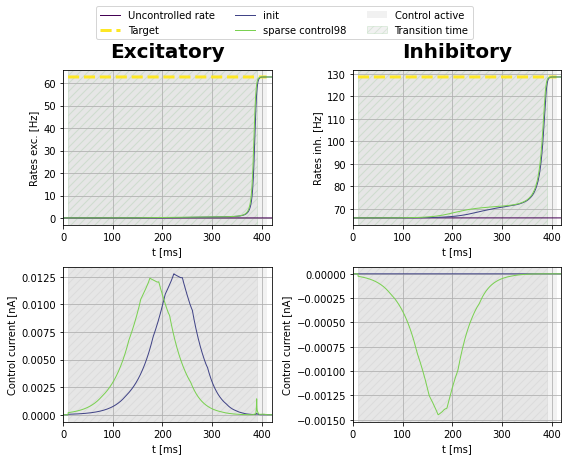

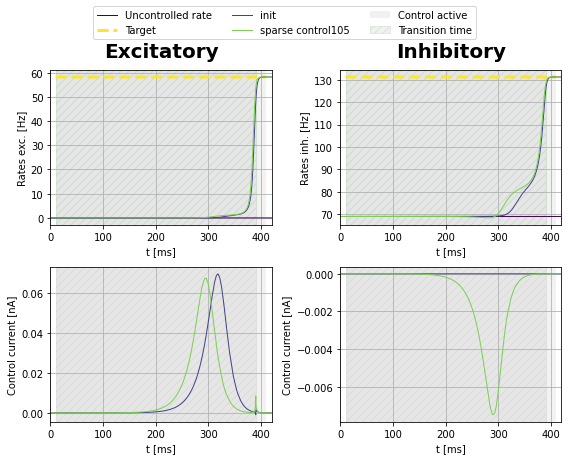

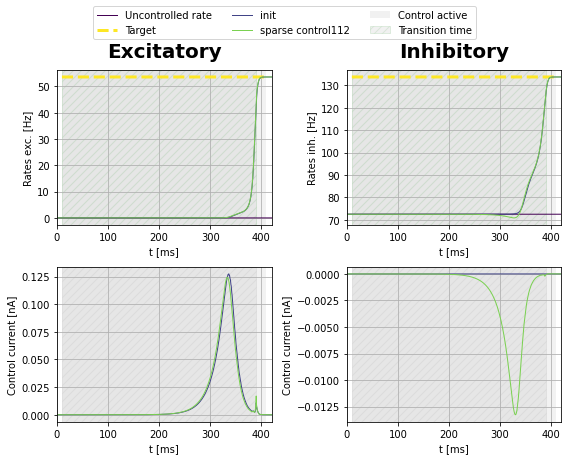

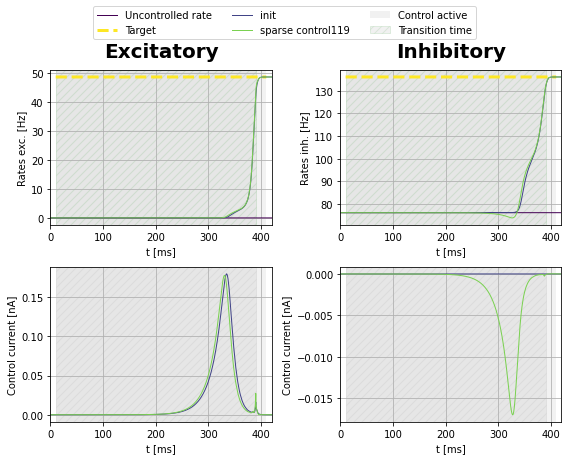

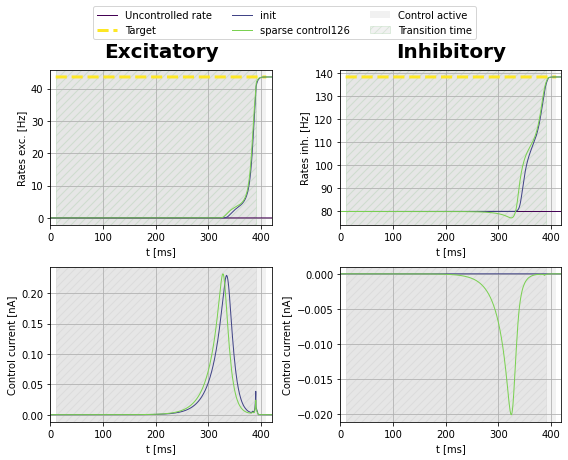

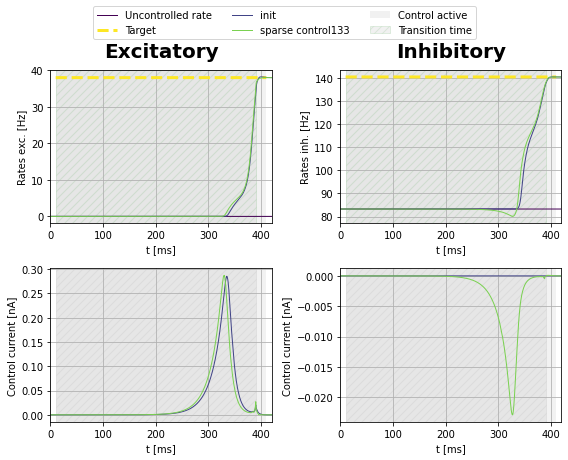

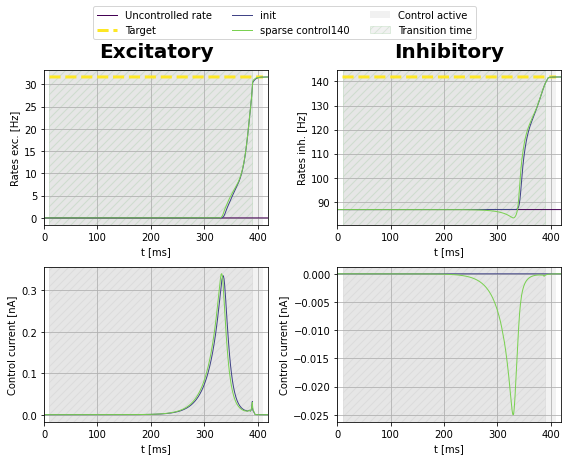

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  19941.452693530668
set cost params:  1.0 19941.452693530668 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5884.190723433081
Gradient descend method:  None
RUN  1 , total integrated cost =  5879.931277204866
RUN  2 , total integrated cost =  5879.930448477353
RUN  3 , total integrated cost =  5879.930407575986
RUN  4 , total integrated cost =  5879.9304041740725
RUN  5 , total integrated cost =  5879.93040393225
RUN  6 , total integrated cost =  5879.930403909465
RUN  7 , total integrated cost =  5879.930403907431
RUN  8 , total integra

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  5879.9304039072185
RUN  12 , total integrated cost =  5879.9304039072185
Control only changes marginally.
RUN  12 , total integrated cost =  5879.9304039072185
Improved over  12  iterations in  2.803223166614771  seconds by  0.07240281163723239  percent.
Problem in initial value trasfer:  Vmean_exc -56.62683225402081 -56.62683710721886
-------  7 0.4500000000000001 0.40000000000000013
no convergence
weight =  37406.296694972465
set cost params:  1.0 37406.296694972465 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13555.506991868788
Gradient descend method:  None
RUN  1 , total integrated cost =  13552.23212378673
RUN  2 , total integrated cost =  13550.827518858841
RUN  3 , total integrated cost =  13549.045548705923
RUN  4 , total integrated cost =  13547.566328601803
RUN  5 , total integrated cost =  13545.523449580865
RUN  6 , total integrated cost =  13544.086409396512
RUN  7 , total integrated cost =  13542.573142137

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1826 , total integrated cost =  12425.875397626489
Improved over  1826  iterations in  206.67616509832442  seconds by  8.333377681261965  percent.
Problem in initial value trasfer:  Vmean_exc -56.674108475105236 -56.67410993476723
-------  14 0.4250000000000001 0.4500000000000002
no convergence
weight =  2532.029577878912
set cost params:  1.0 2532.029577878912 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8791.95671500557
Gradient descend method:  None
RUN  1 , total integrated cost =  8791.513695092784
RUN  2 , total integrated cost =  8791.323057920523
RUN  3 , total integrated cost =  8791.151909416132
RUN  4 , total integrated cost =  8790.924440842482
RUN  5 , total integrated cost =  8790.648073738032
RUN  6 , total integrated cost =  8790.444690114104
RUN  7 , total integrated cost =  8790.218944254893
RUN  8 , total integrated cost =  8790.028042449314
RUN  9 , total integrated cost =  8789.852349900808
RUN  1

...

RUN  2 , total integrated cost =  5902.111628010954
Control only changes marginally.
RUN  2 , total integrated cost =  5902.111628010954
Improved over  2  iterations in  0.8780431635677814  seconds by  1.4210854715202004e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.62683078707549 -56.62683565469593
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
--

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28710.250443635916
Control only changes marginally.
RUN  1 , total integrated cost =  28710.250443635916
Improved over  1  iterations in  0.4602908715605736  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.704083634427505 -56.704083571886954
-------  119 0.5250000000000001 0.8250000000000005
converged for  119
-------  126 0.5000000000000002 0.8500000000000005
converged for  126
-------  133 0.47500000000000014 0.8750000000000006
converged for  133
-------  140 0.4500000000000001 0.9000000000000006
converged for  140
--------------- 8
[[False, False], [True, False], [True, False], [True, True], [True, False], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  20017.253038102408
set

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5902.111628010955
Control only changes marginally.
RUN  1 , total integrated cost =  5902.111628010955
Improved over  1  iterations in  0.4552571289241314  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62683078707549 -56.62683565469593
-------  7 0.4500000000000001 0.40000000000000013
converged for  7
-------  14 0.4250000000000001 0.4500000000000002
converged for  14
-------  21 0.47500000000000014 0.4750000000000002
converged for  21
-------  28 0.5000000000000002 0.5000000000000002
converged for  28
-------  35 0.5500000000000003 0.5250000000000002
converged for  35
-------  42 0.4250000000000001 0.5750000000000003
converged for  42
-------  49 0.4500000000000001 0.6000000000000003
converged for  49
-------  56 0.4500000000000001 0.6250000000000003
converged for  56
-------  63 0.4500000000000001 0.6500000000000004
converged for  63
-------  70 0.4500000000000001 0.6750000000000004
converged for  70
-------  77 0.4500000

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0   7  14  21  28  35  42  49  56  63  70  77  84  91  98 105 112 119
 126 133 140]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  44.92928422305372
Gradient descend method:  None
RUN  1 , total integrated cost =  0.5176408808575035
RUN  2 , total integrated cost =  0.3421223336532405
RUN  3 , total integrated cost =  0.32857396786336196
RUN  4 , total integrated cost =  0.32265314820742685
RUN  5 , total integrated cost =  0.31855634750178957
RUN  6 , total integrated cost =  0.3159348024458015
RUN  7 , total integrated cost =  0.31426077360958793
RUN  8 , total integrated cost =  0.31335508148681207
RUN  9 , total integrated cost =  0.31271326974486713
RUN  10 , total integrated cost =  0.31225476514739353
RUN  11 , total integrated cost =  0.3118703023100011
RUN  12 , total integrated cost =  0.31158965082399376
RUN  13 , total integrated cost =  0.3113490536989175
RUN  14 , total integrated cost =  0.31114848340222806
RUN  15 , total integrated cost =  0.3109670

RUN  3 , total integrated cost =  2.1022700245181367
RUN  4 , total integrated cost =  2.098423848110675
RUN  5 , total integrated cost =  2.095450785067053
RUN  6 , total integrated cost =  2.092820361771941
RUN  7 , total integrated cost =  2.0907095860230003
RUN  8 , total integrated cost =  2.0888651560819387
RUN  9 , total integrated cost =  2.0874050493371543
RUN  10 , total integrated cost =  2.08612498204614
RUN  11 , total integrated cost =  2.0850909725133895
RUN  12 , total integrated cost =  2.0842439528077206
RUN  13 , total integrated cost =  2.0835180567683453
RUN  14 , total integrated cost =  2.082914431846962
RUN  15 , total integrated cost =  2.0823779429725167
RUN  16 , total integrated cost =  2.081920292174699
RUN  17 , total integrated cost =  2.081493789108014
RUN  18 , total integrated cost =  2.0811363461858776
RUN  19 , total integrated cost =  2.080760808270397
RUN  20 , total integrated cost =  2.0804333753538886
RUN  30 , total integrated cost =  2.0782115

RUN  3 , total integrated cost =  16.16337462572758
RUN  4 , total integrated cost =  16.15811544755496
RUN  5 , total integrated cost =  16.145768593260474
RUN  6 , total integrated cost =  16.134896441133346
RUN  7 , total integrated cost =  15.855557112769528
RUN  8 , total integrated cost =  15.839490953682773
RUN  9 , total integrated cost =  15.83170574685435
RUN  10 , total integrated cost =  15.824140567050856
RUN  11 , total integrated cost =  15.820828902858821
RUN  12 , total integrated cost =  15.81758400250072
RUN  13 , total integrated cost =  15.814434004635757
RUN  14 , total integrated cost =  15.811599165262827
RUN  15 , total integrated cost =  15.808101532531785
RUN  16 , total integrated cost =  15.804573476329017
RUN  17 , total integrated cost =  15.800175678573328
RUN  18 , total integrated cost =  15.79600712413075
RUN  19 , total integrated cost =  15.788352514396195
RUN  20 , total integrated cost =  15.781818078569218
RUN  30 , total integrated cost =  15.76

RUN  800 , total integrated cost =  17.15941597680016
RUN  900 , total integrated cost =  17.15932105206887
RUN  1000 , total integrated cost =  17.159310432922815
RUN  1100 , total integrated cost =  17.15929998084981
RUN  1200 , total integrated cost =  17.159231654738313
RUN  1300 , total integrated cost =  17.159118627271575
RUN  1400 , total integrated cost =  17.15910501412737
RUN  1500 , total integrated cost =  17.15909659935968
RUN  1600 , total integrated cost =  17.159078031132935
RUN  1700 , total integrated cost =  17.15880065575767
RUN  1800 , total integrated cost =  17.15878074320014
RUN  1900 , total integrated cost =  17.158713191054357
RUN  2000 , total integrated cost =  17.15869849865331
Control only changes marginally.
RUN  2136 , total integrated cost =  17.15843579008795
Improved over  2136  iterations in  129.82983249425888  seconds by  18.64996524461226  percent.
-------  63 0.4500000000000001 0.6500000000000004
set cost params:  1.0 1.0 0.0
interpolate adjoin

ERROR:root:Problem in initial value trasfer


...

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1331 , total integrated cost =  22.87565212056645
Improved over  1331  iterations in  83.53855552151799  seconds by  10.868004597455524  percent.
Problem in initial value trasfer:  Vmean_exc -56.65805909943572 -56.65805904079933
-------  84 0.4500000000000001 0.7250000000000004
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26.364603104857338
Gradient descend method:  None
RUN  1 , total integrated cost =  24.177060140965693
RUN  2 , total integrated cost =  24.17521020132168
RUN  3 , total integrated cost =  24.174696260536738
RUN  4 , total integrated cost =  24.17409615843333
RUN  5 , total integrated cost =  24.1737660596225
RUN  6 , total integrated cost =  24.1733816159699
RUN  7 , total integrated cost =  24.17320984879053
RUN  8 , total integrated cost =  24.17296589126284
RUN  9 , total integrated cost =  24.172835733521378
RUN  10 , total integrated cost =  24.172637424148938
RUN  11 

RUN  90 , total integrated cost =  0.1463114663855388
RUN  100 , total integrated cost =  0.1462845281765379
RUN  110 , total integrated cost =  0.1462592192614477
RUN  120 , total integrated cost =  0.14623448255996851
RUN  130 , total integrated cost =  0.1462100823061971
RUN  140 , total integrated cost =  0.14618592934590943
RUN  150 , total integrated cost =  0.14616170659933092
RUN  160 , total integrated cost =  0.14613930526039523
RUN  170 , total integrated cost =  0.14611845755184222
RUN  180 , total integrated cost =  0.14609876570843983
RUN  190 , total integrated cost =  0.14608130919807585
RUN  200 , total integrated cost =  0.14606552390551564
RUN  300 , total integrated cost =  0.14597204726863655
RUN  400 , total integrated cost =  0.14594174530332543
RUN  500 , total integrated cost =  0.1459388201261706
RUN  600 , total integrated cost =  0.14593701949301663
RUN  700 , total integrated cost =  0.14593627379689256
RUN  800 , total integrated cost =  0.1459347217936665

RUN  1500 , total integrated cost =  5.3126913693549715
RUN  1600 , total integrated cost =  5.312383365750623
RUN  1700 , total integrated cost =  5.312363291152701
RUN  1800 , total integrated cost =  5.312317139628054
RUN  1900 , total integrated cost =  5.312010363053416
RUN  2000 , total integrated cost =  5.311931228628747
Control only changes marginally.
RUN  2727 , total integrated cost =  5.309504194047688
Improved over  2727  iterations in  164.07033398374915  seconds by  90.94380830683767  percent.
-------  119 0.5250000000000001 0.8250000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24.351921468378784
Gradient descend method:  None
RUN  1 , total integrated cost =  9.703310049895942
RUN  2 , total integrated cost =  9.703126598424287
RUN  3 , total integrated cost =  9.702901454036473
RUN  4 , total integrated cost =  9.70272106094142
RUN  5 , total integrated cost =  9.70247977218887
RUN  6 , total integrate

RUN  150 , total integrated cost =  21.72435264073762
RUN  160 , total integrated cost =  21.723022571486304
RUN  170 , total integrated cost =  21.721365309125048
RUN  180 , total integrated cost =  21.714118839751364
RUN  190 , total integrated cost =  21.712639805197174
RUN  200 , total integrated cost =  21.711470829553505
RUN  300 , total integrated cost =  21.709720167599375
RUN  400 , total integrated cost =  21.70801842272434
RUN  500 , total integrated cost =  21.70696166711865
RUN  600 , total integrated cost =  21.70605200821737
RUN  700 , total integrated cost =  21.705396932321822
RUN  800 , total integrated cost =  21.70488384124605
RUN  900 , total integrated cost =  21.704452182831204
RUN  1000 , total integrated cost =  21.703913391609916
RUN  1100 , total integrated cost =  21.703671474665224
RUN  1200 , total integrated cost =  21.703031962458578
RUN  1300 , total integrated cost =  21.702234580736484
RUN  1400 , total integrated cost =  21.70199280046511
RUN  1500 ,

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3033862571187523
Gradient descend method:  None
RUN  1 , total integrated cost =  0.3033862571187523
Control only changes marginally.
RUN  1 , total integrated cost =  0.3033862571187523
Improved over  1  iterations in  0.14929882809519768  seconds by  0.0  percent.
-------  7 0.4500000000000001 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.33338964799571963
Gradient descend method

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  19.844936263271663
Control only changes marginally.
RUN  1 , total integrated cost =  19.844936263271663
Improved over  1  iterations in  0.165034968405962  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.66008548915629 -56.66008543476922
-------  70 0.4500000000000001 0.6750000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21.53832442222158
Gradient descend method:  None
RUN  1 , total integrated cost =  21.53832442222158
Control only changes marginally.
RUN  1 , total integrated cost =  21.53832442222158
Improved over  1  iterations in  0.16219882853329182  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65904061756306 -56.65904065375913
-------  77 0.4500000000000001 0.7000000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22.87565212056645

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  22.87565212056645
Control only changes marginally.
RUN  1 , total integrated cost =  22.87565212056645
Improved over  1  iterations in  0.15738402120769024  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65805909943572 -56.65805904079933
-------  84 0.4500000000000001 0.7250000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24.06774113555178
Gradient descend method:  None
RUN  1 , total integrated cost =  24.06774113555178
Control only changes marginally.
RUN  1 , total integrated cost =  24.06774113555178
Improved over  1  iterations in  0.16363701410591602  seconds by  0.0  percent.
-------  91 0.4250000000000001 0.7500000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32.69372992040139
Gradient descend method:  None
RUN  1 , total integrated cost =  32.69372992040139

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
